In [1]:
#STEP 1
#Load Dataset and Inspect Target Variable
import pandas as pd

# Load dataset
df = pd.read_csv("airline_passenger_satisfaction.csv")

# Basic inspection
print(df.shape)
print(df.head())

# Check target variable distribution
print(df["satisfaction"].value_counts())
print(df["satisfaction"].value_counts(normalize=True) * 100)

(129880, 22)
  satisfaction   Customer Type  Age   Type of Travel     Class  \
0    satisfied  Loyal Customer   65  Personal Travel       Eco   
1    satisfied  Loyal Customer   47  Personal Travel  Business   
2    satisfied  Loyal Customer   15  Personal Travel       Eco   
3    satisfied  Loyal Customer   60  Personal Travel       Eco   
4    satisfied  Loyal Customer   70  Personal Travel       Eco   

   Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0              265             0                                  0   
1             2464             0                                  0   
2             2138             0                                  0   
3              623             0                                  0   
4              354             0                                  0   

   Food and drink  Gate location  ...  Online support  Ease of Online booking  \
0               0              2  ...               2                       3   
1

In [2]:
#STEP 2
#Encode Categorical Predictors
from sklearn.model_selection import train_test_split

# Convert target to binary
df["satisfaction"] = df["satisfaction"].map({
    "dissatisfied": 0,
    "satisfied": 1
})

# Separate features and target
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

# Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
print(categorical_cols)

Index(['Customer Type', 'Type of Travel', 'Class'], dtype='str')


C:\Users\butte\AppData\Local\Temp\ipykernel_10564\3990598298.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [5]:
#Use One-Hot Encoding:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(drop="first"))
            ]),
            categorical_cols
        )
    ]
)

In [6]:
#STEP 3
#Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(103904, 21)
(25976, 21)


In [7]:
#STEP 4
#Build Binomial Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

C:\Users\butte\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Customer Type','Age','Type of Travel',...,'Online boarding', 'Departure Delay in Minutes','Arrival Delay in Minutes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dro

In [8]:
#STEP 5
# Probability of being satisfied
probabilities = model.predict_proba(X_test)

print(probabilities[:5])

[[0.09802335 0.90197665]
 [0.15931604 0.84068396]
 [0.9430381  0.0569619 ]
 [0.05242796 0.94757204]
 [0.65478967 0.34521033]]


In [9]:
#STEP 6
#Confusion Matrix, Precision and Recall
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    accuracy_score
)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Confusion Matrix
[[ 9227  2532]
 [ 2233 11984]]

Accuracy: 0.8165614413304589
Precision: 0.8255717828602921
Recall: 0.8429345150172329


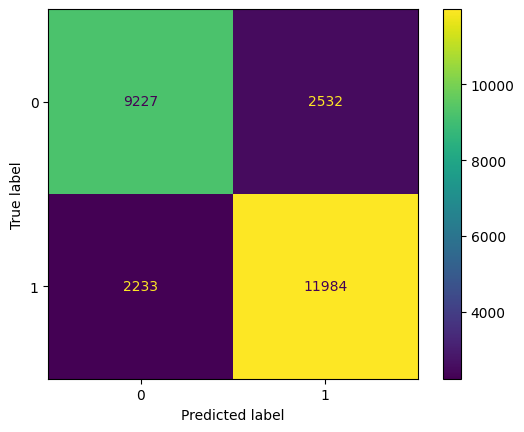

In [10]:
#Visualize:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [11]:
#STEP 7
#Interpret Model Coefficients
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = model.named_steps[
    "classifier"
].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(coef_df.head(10))
print(coef_df.tail(10))

                            Feature  Coefficient
7       num__Inflight entertainment     0.697351
9       num__Ease of Online booking     0.410798
10            num__On-board service     0.280138
2                 num__Seat comfort     0.279003
11            num__Leg room service     0.173005
13             num__Checkin service     0.172350
8               num__Online support     0.076152
15             num__Online boarding     0.061791
16  num__Departure Delay in Minutes     0.002468
1              num__Flight Distance    -0.000363
                                   Feature  Coefficient
12                   num__Baggage handling    -0.028660
5                       num__Gate location    -0.034737
14                        num__Cleanliness    -0.081720
3   num__Departure/Arrival time convenient    -0.209067
4                      num__Food and drink    -0.220128
6               num__Inflight wifi service    -0.231623
19     cat__Type of Travel_Personal Travel    -0.532310
21           

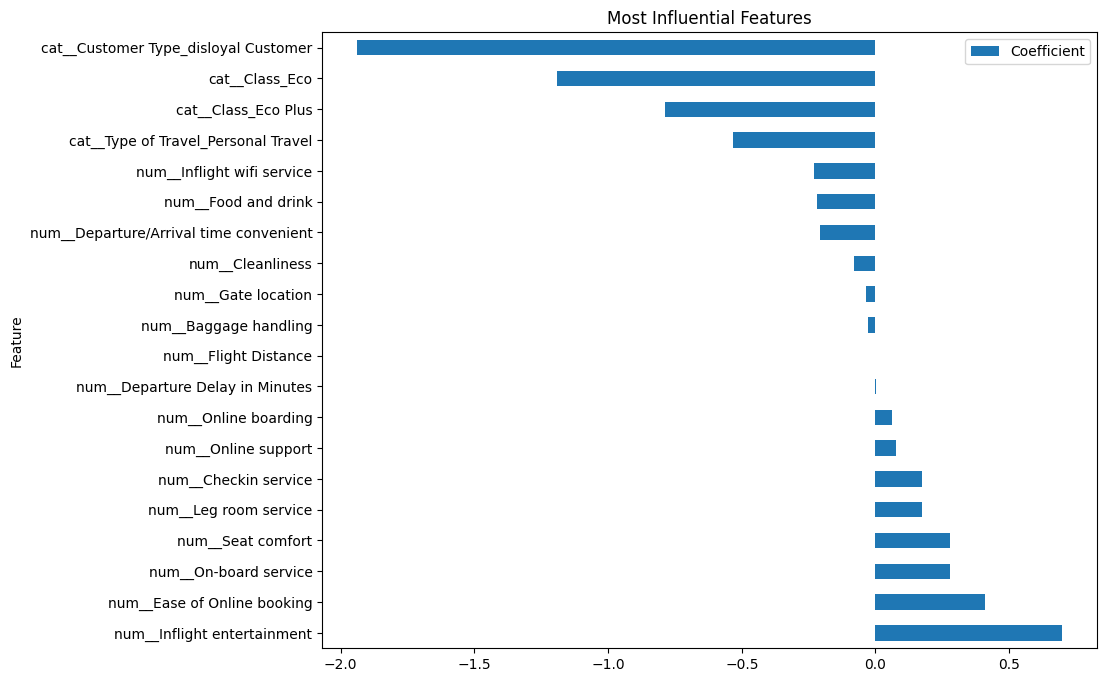

In [12]:
#STEP 8
#Visualize Most Important Drivers
top_features = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
])

top_features.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    figsize=(10,8)
)

plt.title("Most Influential Features")
plt.show()

Conclusion (for report)

The Logistic Regression model successfully predicts customer satisfaction using operational and service-related variables. Key satisfaction drivers include inflight entertainment, online boarding, seat comfort, cleanliness, and onboard service, while delays and poor convenience-related services reduce satisfaction. Management should prioritize operational reliability and passenger experience improvements to increase customer satisfaction and loyalty.